In [1]:
# ── Cài đặt dependencies ─────────────────────────────────────────
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install numpy seaborn pandas matplotlib tqdm scikit-learn -q


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Imports & GPU check
# ════════════════════════════════════════════════════════════════
import copy, time, json, warnings, shutil
import torch.nn.functional as F
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(123)
np.random.seed(123)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(123)
    torch.backends.cudnn.benchmark = True

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : NVIDIA GeForce RTX 3060
VRAM    : 12.5 GB


In [3]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Config (TCN Thuần túy)
# ════════════════════════════════════════════════════════════════
from pathlib import Path

# ── Paths ───────────────────────────────────────────────────────
DRIVE_FOLDER = Path('/workspace/data')
OUT_DIR      = Path('/workspace/data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ─────────────────────────────────────────────────────
SLEEP_STAGES  = ['W', 'N1', 'N2', 'N3', 'REM']
N_CLASSES     = 5
EPOCH_SAMPLES = 3000          
N_FOLDS       = 10

# ── ResNet-1D hyperparams (Giai đoạn 1 — chỉ LOAD) ─────────────
N_FEAT            = 128

# ── TCN hyperparams ─────────────────────────────────────────────
TCN_DIM         = 128          
TCN_KERNEL_SIZE = 3            
TCN_BLOCKS      = 6            
TCN_DROPOUT     = 0.2          

# ── Sequence training hyperparams (Giai đoạn 2) ─────────────────
SEQ_LR         = 5e-4          # TCN thuần túy có thể dùng LR cao hơn chút
SEQ_BATCH_SIZE = 8             # Tăng batch size vì không tốn VRAM cho SCL
SEQ_MAX_EPOCHS = 300           
SEQ_PATIENCE   = 30            
SEQ_VAL_EVERY  = 5
SEQ_VAL_RATIO  = 0.10

# ── Class weights ────────────────────────────────────────────────
CE_CLASS_WEIGHTS = [1.0, 1.0, 1.0, 1.0, 1.0]

print('✓ Config TCN Thuần túy OK')

✓ Config TCN Thuần túy OK


In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Load NPZ files & xây dựng subject map
# ════════════════════════════════════════════════════════════════

def find_npz_dir(root: Path) -> Path:
    for p in sorted(root.rglob('SC*.npz')):
        return p.parent
    raise FileNotFoundError(f'Không tìm thấy file SC*.npz trong {root}')

NPZ_DIR   = find_npz_dir(DRIVE_FOLDER)
NPZ_FILES = sorted(NPZ_DIR.glob('SC*.npz'))
print(f'✓ Tìm thấy {len(NPZ_FILES)} NPZ files trong {NPZ_DIR}')

def normalize_labels(y: np.ndarray) -> np.ndarray:
    y = y.astype(np.int64).ravel()
    if y.min() == 1 and y.max() <= 5:
        y = y - 1
    y[(y < 0) | (y >= N_CLASSES)] = -1
    return y

def load_npz(fpath: Path):
    d    = np.load(str(fpath), allow_pickle=True)
    sigs = d['x'].astype(np.float32)
    lbls = normalize_labels(d['y'])
    if sigs.ndim == 3:
        sigs = sigs[:, 0, :]
    if sigs.ndim == 2 and sigs.shape[1] != EPOCH_SAMPLES:
        sigs = sigs.T
    sleep_idx = np.where((lbls >= 1) & (lbls <= 4))[0]
    if len(sleep_idx) > 0:
        s = max(0, sleep_idx[0] - 60)
        e = min(len(lbls), sleep_idx[-1] + 61)
        sigs, lbls = sigs[s:e], lbls[s:e]
    assert sigs.shape[1] == EPOCH_SAMPLES, f'shape lỗi: {sigs.shape}'
    return sigs, lbls

subject_records = defaultdict(list)
all_records      = []

print(f'\nLoading {len(NPZ_FILES)} files ...')
print(f"{'File':<22} {'Epochs':>6} {'W':>5} {'N1':>5} {'N2':>5} {'N3':>5} {'REM':>5} {'Rác':>5}")
print('─' * 65)

for fpath in NPZ_FILES:
    try:
        sigs, lbls = load_npz(fpath)
        sid  = fpath.stem[3:5]
        cnt  = [int((lbls == i).sum()) for i in range(N_CLASSES)]
        n_gc = int((lbls == -1).sum())
        print(f'  {fpath.name:<20} {len(lbls):>6} '
              + ' '.join(f'{c:>5}' for c in cnt)
              + f' {n_gc:>5}')
        rec = {'sid': sid, 'fname': fpath.stem, 'sigs': sigs, 'lbls': lbls}
        subject_records[sid].append(rec)
        all_records.append(rec)
    except Exception as exc:
        print(f'  ✗ {fpath.name}: {exc}')

subject_ids = sorted(subject_records.keys())
print(f'\n✓ {len(all_records)} records  |  {len(subject_ids)} subjects')

✓ Tìm thấy 153 NPZ files trong /workspace/data

Loading 153 files ...
File                   Epochs     W    N1    N2    N3   REM   Rác
─────────────────────────────────────────────────────────────────
  SC4001E0.npz            841   188    58   250   220   125     0
  SC4002E0.npz           1127   183    59   373   297   215     0
  SC4011E0.npz           1103   157   109   562   105   170     0
  SC4012E0.npz           1186   162    92   660    96   176     0
  SC4021E0.npz           1025   128    94   545    95   163     0
  SC4022E0.npz           1009   125   184   402   119   179     0
  SC4031E0.npz            952   140    61   485    57   209     0
  SC4032E0.npz            911   136    45   400   131   199     0
  SC4041E0.npz           1235   200   166   620    53   196     0
  SC4042E0.npz           1200   185   137   514    94   270     0
  SC4051E0.npz            672   208    44   217   135    68     0
  SC4052E0.npz           1246   222   114   616   114   180     0
  SC40

In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Tạo 10-fold subject-wise split (CÙNG logic với extract_new)
# ════════════════════════════════════════════════════════════════
rng = np.random.default_rng(seed=123)
shuffled_ids = rng.permutation(subject_ids).tolist()
fold_groups  = np.array_split(shuffled_ids, N_FOLDS)

print(f'10-fold subject-wise CV  (seed=123)')
for i, grp in enumerate(fold_groups):
    sids_list = list(grp)
    n_rec  = sum(len(subject_records[s]) for s in sids_list)
    n_ep   = sum(len(r['lbls']) for s in sids_list for r in subject_records[s])
    print(f'  Fold {i+1:2d}: subjects={sids_list}  {n_rec} rec  {n_ep:,} epochs')

10-fold subject-wise CV  (seed=123)
  Fold  1: subjects=[np.str_('74'), np.str_('03'), np.str_('21'), np.str_('01'), np.str_('64'), np.str_('65'), np.str_('10'), np.str_('81')]  16 rec  22,376 epochs
  Fold  2: subjects=[np.str_('77'), np.str_('54'), np.str_('15'), np.str_('71'), np.str_('40'), np.str_('49'), np.str_('31'), np.str_('38')]  16 rec  21,040 epochs
  Fold  3: subjects=[np.str_('13'), np.str_('23'), np.str_('09'), np.str_('17'), np.str_('02'), np.str_('52'), np.str_('00'), np.str_('07')]  14 rec  15,921 epochs
  Fold  4: subjects=[np.str_('34'), np.str_('53'), np.str_('59'), np.str_('32'), np.str_('48'), np.str_('20'), np.str_('66'), np.str_('55')]  16 rec  23,024 epochs
  Fold  5: subjects=[np.str_('28'), np.str_('26'), np.str_('73'), np.str_('76'), np.str_('80'), np.str_('51'), np.str_('14'), np.str_('42')]  16 rec  22,240 epochs
  Fold  6: subjects=[np.str_('04'), np.str_('30'), np.str_('56'), np.str_('19'), np.str_('18'), np.str_('67'), np.str_('43'), np.str_('24')]  16

In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Kiến trúc ResNet-1D (Feature Extractor — GIỮ NGUYÊN)
#           Trọng số được load từ extract_new.ipynb
# ════════════════════════════════════════════════════════════════

class ResNetBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        res = self.shortcut(x)
        x   = self.relu(self.bn1(self.conv1(x)))
        x   = self.bn2(self.conv2(x))
        return self.relu(x + res)


class EEG_ResNet1D(nn.Module):
    def __init__(self, feature_dim=128, num_classes=5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=50, stride=5, padding=25, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = ResNetBlock1D(32, 64, stride=1)
        self.layer2 = ResNetBlock1D(64, 128, stride=2)
        self.layer3 = ResNetBlock1D(128, feature_dim, stride=2)
        self.gap     = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(p=0.5)
        self.fc      = nn.Linear(feature_dim, num_classes)

    def forward(self, x, extract_features=False):
        x        = self.stem(x)
        x        = self.layer1(x)
        x        = self.layer2(x)
        x        = self.layer3(x)
        features = self.gap(x).squeeze(-1)
        if extract_features:
            return features
        return self.fc(self.dropout(features))

_m = EEG_ResNet1D().to(DEVICE)
_x = torch.randn(2, 1, EPOCH_SAMPLES).to(DEVICE)
_f = _m(_x, extract_features=True)
_n = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'✓ EEG_ResNet1D params={_n:,}  feature shape={_f.shape}')
del _m, _x, _f

✓ EEG_ResNet1D params=475,269  feature shape=torch.Size([2, 128])


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Kiến trúc SleepTCN (Thuần túy)
# ════════════════════════════════════════════════════════════════

class TemporalBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int, dilation: int, dropout: float = 0.2):
        super().__init__()
        pad = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation, bias=False)
        self.norm1 = nn.LayerNorm(out_ch)
        self.act1  = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation, bias=False)
        self.norm2 = nn.LayerNorm(out_ch)
        self.act2  = nn.GELU()
        self.drop2 = nn.Dropout(dropout)
        self.residual = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        res = self.residual(x)
        out = self.conv1(x)
        out = self.norm1(out.transpose(1, 2)).transpose(1, 2)
        out = self.drop1(self.act1(out))
        out = self.conv2(out)
        out = self.norm2(out.transpose(1, 2)).transpose(1, 2)
        out = self.drop2(self.act2(out))
        return out + res

class SleepTCN(nn.Module):
    def __init__(self, input_size=N_FEAT, dim=TCN_DIM, kernel_size=TCN_KERNEL_SIZE, n_blocks=TCN_BLOCKS, dropout=TCN_DROPOUT, n_classes=N_CLASSES):
        super().__init__()
        self.input_proj = nn.Sequential(nn.Linear(input_size, dim), nn.LayerNorm(dim), nn.GELU())
        blocks = []
        for i in range(n_blocks):
            blocks.append(TemporalBlock(dim, dim, kernel_size, dilation=2**i, dropout=dropout))
        self.tcn = nn.Sequential(*blocks)
        self.classifier = nn.Linear(dim, n_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        # x: (B, T, input_size)
        h = self.input_proj(x)
        h = h.transpose(1, 2) # (B, dim, T)
        h = self.tcn(h)
        h = h.transpose(1, 2) # (B, T, dim)
        return self.classifier(self.dropout(h))

print('✓ SleepTCN Thuần túy ready')

✓ SleepTCN Thuần túy ready


In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Dataset CNN (3 manipulation sets A/B/C — GIỮ NGUYÊN)
# ════════════════════════════════════════════════════════════════

class EEGSleepDataset(Dataset):
    def __init__(self, signals, labels, manipulation='A'):
        valid = labels != -1
        self.labels  = labels[valid].astype(np.int64)
        sigs_v       = signals[valid]
        if manipulation == 'A':
            self.signals = sigs_v
        elif manipulation == 'B':
            prev = np.concatenate([signals[:1], signals[:-1]], 0)
            self.signals = prev[valid]
        else:
            nxt = np.concatenate([signals[1:], signals[-1:]], 0)
            self.signals = nxt[valid]

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.signals[idx].astype(np.float32)).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

print('✓ EEGSleepDataset ready')

✓ EEGSleepDataset ready


In [9]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Load ResNet từ extract_new & Extract Features
# ════════════════════════════════════════════════════════════════
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score as sk_f1


class _SimpleEEGDataset(Dataset):
    def __init__(self, signals, labels):
        self.signals = signals
        self.labels  = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.signals[idx].astype(np.float32)).unsqueeze(0)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


@torch.no_grad()
def extract_features_resnet(records_list, resnet_model):
    """Trích xuất vector 128-dim từ ResNet, giữ nguyên sequence."""
    resnet_model.eval()
    results = []
    for rec in records_list:
        sigs = rec['sigs']
        lbls = rec['lbls']
        feats = []
        for i in range(0, len(sigs), 256):
            xb = torch.from_numpy(
                sigs[i:i+256].astype(np.float32)).unsqueeze(1).to(DEVICE)
            batch_feat = resnet_model(xb, extract_features=True)
            feats.append(batch_feat.cpu().numpy())
        feats = np.concatenate(feats, axis=0)
        results.append((feats, lbls))
    return results

print('✓ extract_features_resnet ready')

✓ extract_features_resnet ready


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — Sequence Dataset, SeqAug, CollateFunction (GIỮ NGUYÊN)
# ════════════════════════════════════════════════════════════════

class RecordDataset(Dataset):
    """Wrap list of (feats, lbls) tuples — không augment."""
    def __init__(self, feat_lbl_list):
        self.data = feat_lbl_list
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        feats, lbls = self.data[idx]
        x = torch.from_numpy(feats.astype(np.float32))
        y = torch.from_numpy(lbls.astype(np.int64))
        return x, y


class SeqAugDataset(Dataset):
    """Augmentation: random skip 0–SEQ_AUG_MAX_SKIP epochs per sequence."""
    def __init__(self, feat_lbl_list, augment=True):
        self.data    = feat_lbl_list
        self.augment = augment
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        feats, lbls = self.data[idx]
        if self.augment and SEQ_AUG_ENABLED:
            skip = np.random.randint(0, SEQ_AUG_MAX_SKIP + 1)
            if skip > 0 and len(feats) > skip + 1:
                start = np.random.randint(0, skip + 1)
                feats, lbls = feats[start:], lbls[start:]
        x = torch.from_numpy(feats.astype(np.float32))
        y = torch.from_numpy(lbls.astype(np.int64))
        return x, y


def collate_pad(batch):
    """Pad sequences trong batch đến cùng độ dài."""
    xs, ys = zip(*batch)
    T_max  = max(x.shape[0] for x in xs)
    B      = len(xs)
    D      = xs[0].shape[1]

    x_pad    = torch.zeros(B, T_max, D)
    y_pad    = torch.full((B, T_max), -100, dtype=torch.long)
    pad_mask = torch.ones(B, T_max, dtype=torch.bool)   # True = pad

    for i, (x, y) in enumerate(zip(xs, ys)):
        T = x.shape[0]
        x_pad[i, :T] = x
        y_pad[i, :T] = y
        pad_mask[i, :T] = False

    return x_pad, y_pad, pad_mask

print('✓ Sequence datasets & collate_pad ready')

✓ Sequence datasets & collate_pad ready


In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — Training Loop (CrossEntropy Only)
# ════════════════════════════════════════════════════════════════

def train_seq_model(model, tr_ld, vl_ld, loss_fn_ce):
    opt = optim.AdamW(model.parameters(), lr=SEQ_LR, weight_decay=1e-3)
    best_loss  = float('inf')
    no_improve = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, SEQ_MAX_EPOCHS + 1):
        model.train()
        for xb, yb, mask in tr_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb) # (B, T, C)
            # Logits: (B, C, T), yb: (B, T)
            loss = loss_fn_ce(logits.permute(0, 2, 1), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        if epoch % SEQ_VAL_EVERY == 0:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for xv, yv, mv in vl_ld:
                    xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                    pred = model(xv)
                    val_loss += loss_fn_ce(pred.permute(0, 2, 1), yv).item()
            val_loss /= len(vl_ld)
            
            if val_loss < best_loss:
                best_loss = val_loss
                no_improve = 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                no_improve += 1
            
            if no_improve >= (SEQ_PATIENCE // SEQ_VAL_EVERY):
                model.load_state_dict(best_state)
                return model, epoch
                
    model.load_state_dict(best_state)
    return model, SEQ_MAX_EPOCHS

print('✓ Training loop đơn giản ready')

✓ Training loop đơn giản ready


In [12]:
# ════════════════════════════════════════════════════════════════
# CELL 11 — Evaluate (GIỮ NGUYÊN — interface giống Conformer)
# ════════════════════════════════════════════════════════════════

def evaluate_model(model, feat_lbl_list):
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for feats, lbls in feat_lbl_list:
            xb   = torch.from_numpy(feats.astype(np.float32)).unsqueeze(0).to(DEVICE)
            pb   = model(xb).squeeze(0).cpu().numpy()
            pred = pb.argmax(axis=1)
            valid = (lbls >= 0) & (lbls < N_CLASSES)
            all_p.append(pred[valid])
            all_t.append(lbls[valid])
    return np.concatenate(all_p), np.concatenate(all_t)


def compute_metrics(preds, trues):
    acc   = accuracy_score(trues, preds)
    mf1   = f1_score(trues, preds, average='macro',  zero_division=0)
    kappa = cohen_kappa_score(trues, preds)
    f1s   = f1_score(trues, preds, average=None,
                     labels=list(range(N_CLASSES)), zero_division=0)
    return {'acc': acc, 'mf1': mf1, 'kappa': kappa,
            **{f'f1_{s}': float(f1s[i]) for i, s in enumerate(SLEEP_STAGES)}}


def print_fold_result(fold_i, m, elapsed):
    print(f"  ACC={m['acc']*100:.2f}%  MF1={m['mf1']*100:.2f}%  "
          f"k={m['kappa']:.4f}  "
          f"[W={m['f1_W']*100:.1f} "
          f"N1={m['f1_N1']*100:.1f} "
          f"N2={m['f1_N2']*100:.1f} "
          f"N3={m['f1_N3']*100:.1f} "
          f"REM={m['f1_REM']*100:.1f}]  "
          f"({elapsed:.0f}s)")

print('✓ Evaluation utilities ready')

✓ Evaluation utilities ready


In [13]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — MAIN LOOP [Load ResNet-1D → Extract → Train SleepTCN Vanilla]
# ════════════════════════════════════════════════════════════════
import json, time
import torch, torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader

all_preds    = []
all_trues    = []
fold_metrics = []
fold_times   = []

# Thư mục chứa trọng số ResNet từ extract_new.ipynb
CKPT_DIR     = OUT_DIR / 'saved_models'
TCN_CKPT_DIR = OUT_DIR / 'checkpoints_tcn'
TCN_CKPT_DIR.mkdir(exist_ok=True)

print('=' * 70)
print(f'  10-Fold CV: Load Pre-trained ResNet-1D + Train SleepTCN (Vanilla)')
print(f'  {len(subject_ids)} subjects | Device: {DEVICE}')
print('=' * 70)

total_t0 = time.time()

for fold_i, test_group in enumerate(fold_groups):
    fold_t0   = time.time()
    test_sids  = list(test_group)
    train_sids = [s for g in fold_groups for s in g if s not in test_sids]

    test_recs  = [r for s in test_sids  for r in subject_records[s]]
    train_recs = [r for s in train_sids for r in subject_records[s]]

    print(f"\n{'_'*70}")
    print(f'  FOLD {fold_i+1:2d}/{N_FOLDS}  test: {test_sids}')

    # ── Step 1: Load ResNet-1D weights ────────────────────────────────
    print(f'\n  [1/4] Load ResNet-1D ...')
    resnet_path  = CKPT_DIR / f'resnet_fold{fold_i+1}.pth'
    resnet_model = EEG_ResNet1D(feature_dim=N_FEAT, num_classes=N_CLASSES).to(DEVICE)

    if resnet_path.exists():
        resnet_model.load_state_dict(
            torch.load(resnet_path, map_location=DEVICE, weights_only=True))
        print(f'    ✓ Đã load: {resnet_path.name}')
    else:
        raise FileNotFoundError(f'❌ Không tìm thấy {resnet_path}.')
    resnet_model.eval()

    # ── Step 2: Extract 128-dim features ──────────────────────────────
    print(f'  [2/4] Extract features via ResNet ...')
    feat_t0      = time.time()
    train_feats  = extract_features_resnet(train_recs, resnet_model)

    # Đổi nhãn rác (-1) → -100 (ignore_index cho CrossEntropy)
    train_feats_seq = []
    for feats, lbls in train_feats:
        lbls_cp = lbls.copy()
        lbls_cp[lbls_cp == -1] = -100
        train_feats_seq.append((feats, lbls_cp))
    print(f'    {len(train_feats_seq)} train records processed ({time.time()-feat_t0:.0f}s)')

    # ── Step 3: Train SleepTCN (Thuần túy) ───────────────────────────
    print(f'  [3/4] Train SleepTCN (Vanilla) ...')
    seq_t0 = time.time()

    # Xáo trộn và chia train/val
    np.random.default_rng(123 + fold_i).shuffle(train_feats_seq)
    n_val    = max(1, int(len(train_feats_seq) * SEQ_VAL_RATIO))
    val_recs = train_feats_seq[:n_val]
    tr_recs  = train_feats_seq[n_val:]

    # Sử dụng RecordDataset thuần túy (Không dùng SeqAugDataset)
    _pin = (DEVICE == 'cuda')
    tr_ld = DataLoader(RecordDataset(tr_recs),  SEQ_BATCH_SIZE,
                       shuffle=True,  collate_fn=collate_pad, num_workers=0,
                       pin_memory=_pin)
    vl_ld = DataLoader(RecordDataset(val_recs), SEQ_BATCH_SIZE,
                       shuffle=False, collate_fn=collate_pad, num_workers=0,
                       pin_memory=_pin)
    print(f'    Train: {len(tr_recs)} rec  |  Val: {len(val_recs)} rec')

    model_seq = SleepTCN(input_size=N_FEAT).to(DEVICE)
    loss_fn_ce = nn.CrossEntropyLoss(
        weight=torch.tensor(CE_CLASS_WEIGHTS, dtype=torch.float32).to(DEVICE),
        ignore_index=-100
    )

    # Huấn luyện với loss CrossEntropy thuần túy
    model_seq, stopped = train_seq_model(model_seq, tr_ld, vl_ld, loss_fn_ce)
    print(f'    Stopped at epoch {stopped} ({time.time()-seq_t0:.0f}s)')

    torch.save(model_seq.state_dict(),
               TCN_CKPT_DIR / f'tcn_vanilla_fold{fold_i+1}.pth')

    # ── Step 4: Evaluate ──────────────────────────────────────────────
    print(f'  [4/4] Evaluate ...')
    test_feats = extract_features_resnet(test_recs, resnet_model)
    fp, ft     = evaluate_model(model_seq, test_feats)

    metrics = compute_metrics(fp, ft)
    metrics.update({
        'fold': fold_i+1, 'test_subjects': test_sids,
        'n_test_epochs': int(len(ft)), 'stopped_epoch': stopped,
    })
    fold_metrics.append(metrics)
    all_preds.extend(fp.tolist())
    all_trues.extend(ft.tolist())

    elapsed = time.time() - fold_t0
    fold_times.append(elapsed)
    print_fold_result(fold_i+1, metrics, elapsed)

    with open(OUT_DIR / 'fold_metrics_resnet_tcn_vanilla.json', 'w') as f:
        json.dump(fold_metrics, f, indent=2)

    del resnet_model, train_feats, train_feats_seq, test_feats, model_seq
    if DEVICE == 'cuda': torch.cuda.empty_cache()

total_elapsed = time.time() - total_t0
print(f'\nTotal: {total_elapsed/3600:.2f}h  (avg {np.mean(fold_times)/60:.1f} min/fold)')

  10-Fold CV: Load Pre-trained ResNet-1D + Train SleepTCN (Vanilla)
  78 subjects | Device: cuda

______________________________________________________________________
  FOLD  1/10  test: [np.str_('74'), np.str_('03'), np.str_('21'), np.str_('01'), np.str_('64'), np.str_('65'), np.str_('10'), np.str_('81')]

  [1/4] Load ResNet-1D ...
    ✓ Đã load: resnet_fold1.pth
  [2/4] Extract features via ResNet ...
    137 train records processed (19s)
  [3/4] Train SleepTCN (Vanilla) ...
    Train: 124 rec  |  Val: 13 rec
    Stopped at epoch 40 (37s)
  [4/4] Evaluate ...
  ACC=86.43%  MF1=81.19%  k=0.8089  [W=93.6 N1=51.7 N2=90.0 N3=85.1 REM=85.6]  (58s)

______________________________________________________________________
  FOLD  2/10  test: [np.str_('77'), np.str_('54'), np.str_('15'), np.str_('71'), np.str_('40'), np.str_('49'), np.str_('31'), np.str_('38')]

  [1/4] Load ResNet-1D ...
    ✓ Đã load: resnet_fold2.pth
  [2/4] Extract features via ResNet ...
    137 train records processed

In [14]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — Kết quả tổng hợp
# ════════════════════════════════════════════════════════════════

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)
overall   = compute_metrics(all_preds, all_trues)

PAPER = {'acc': 84.09, 'mf1': 78.26, 'kappa': 0.7790,
         'f1_W': 93.11, 'f1_N1': 48.31, 'f1_N2': 85.86,
         'f1_N3': 81.16, 'f1_REM': 82.85}

print('\n' + '═' * 70)
print('  KẾT QUẢ — ResNet+TCN (10-fold) vs Paper')
print('═' * 70)
print(f"  {'Metric':<14} {'Ours':>10} {'Paper':>10} {'Diff':>10}")
print(f"  {'─'*46}")

for key, label in [('acc','Accuracy'), ('mf1','Macro F1'), ('kappa','Kappa')]:
    ours  = overall[key] * 100 if key != 'kappa' else overall[key]
    paper = PAPER[key]
    diff  = ours - paper
    sign  = '+' if diff >= 0 else ''
    if key == 'kappa':
        print(f"  {label:<14} {ours:>10.4f} {paper:>10.4f} {sign}{diff:>9.4f}")
    else:
        print(f"  {label:<14} {ours:>9.2f}% {paper:>9.2f}% {sign}{diff:>8.2f}%")

print(f"\n  {'Stage':<8} {'Ours':>8} {'Paper':>8} {'Diff':>8}")
print(f"  {'─'*36}")
for s in SLEEP_STAGES:
    k    = f'f1_{s}'
    ours = overall[k] * 100
    pap  = PAPER[k]
    diff = ours - pap
    sign = '+' if diff >= 0 else ''
    print(f"  {s:<8} {ours:>7.2f}% {pap:>7.2f}% {sign}{diff:>6.2f}%")

print('\n' + classification_report(all_trues, all_preds, target_names=SLEEP_STAGES))

print('\n  Per-fold breakdown:')
print(f"  {'Fold':>5} {'Subjects':<15} {'ACC':>7} {'MF1':>7} {'κ':>7} {'N_ep':>6} {'Time':>7}")
print(f"  {'─'*58}")
for m, t in zip(fold_metrics, fold_times):
    subj_str = str(m['test_subjects'][:3])
    print(f"  {m['fold']:>5} {subj_str:<15} "
          f"{m['acc']*100:>6.2f}% {m['mf1']*100:>6.2f}% "
          f"{m['kappa']:>7.4f} {m['n_test_epochs']:>6,} "
          f"{t/60:>5.1f}m")

print(f"\n  {'MEAN':>5} {'':15} "
      f"{np.mean([m['acc'] for m in fold_metrics])*100:>6.2f}% "
      f"{np.mean([m['mf1'] for m in fold_metrics])*100:>6.2f}% "
      f"{np.mean([m['kappa'] for m in fold_metrics]):>7.4f}")
print(f"  {'STD':>5} {'':15} "
      f"{np.std([m['acc']  for m in fold_metrics])*100:>6.2f}% "
      f"{np.std([m['mf1']  for m in fold_metrics])*100:>6.2f}% "
      f"{np.std([m['kappa'] for m in fold_metrics]):>7.4f}")


══════════════════════════════════════════════════════════════════════
  KẾT QUẢ — ResNet+TCN (10-fold) vs Paper
══════════════════════════════════════════════════════════════════════
  Metric               Ours      Paper       Diff
  ──────────────────────────────────────────────
  Accuracy           83.89%     84.09%    -0.20%
  Macro F1           78.53%     78.26% +    0.27%
  Kappa              0.7775     0.7790   -0.0015

  Stage        Ours    Paper     Diff
  ────────────────────────────────────
  W          92.60%   93.11%  -0.51%
  N1         49.40%   48.31% +  1.09%
  N2         85.93%   85.86% +  0.07%
  N3         81.51%   81.16% +  0.35%
  REM        83.20%   82.85% +  0.35%

              precision    recall  f1-score   support

           W       0.92      0.93      0.93     65951
          N1       0.55      0.45      0.49     21522
          N2       0.85      0.87      0.86     69132
          N3       0.81      0.82      0.82     13039
         REM       0.81      

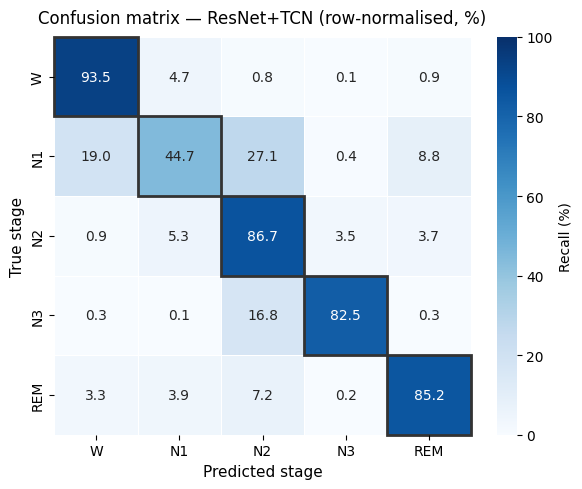

✓ Confusion matrix saved


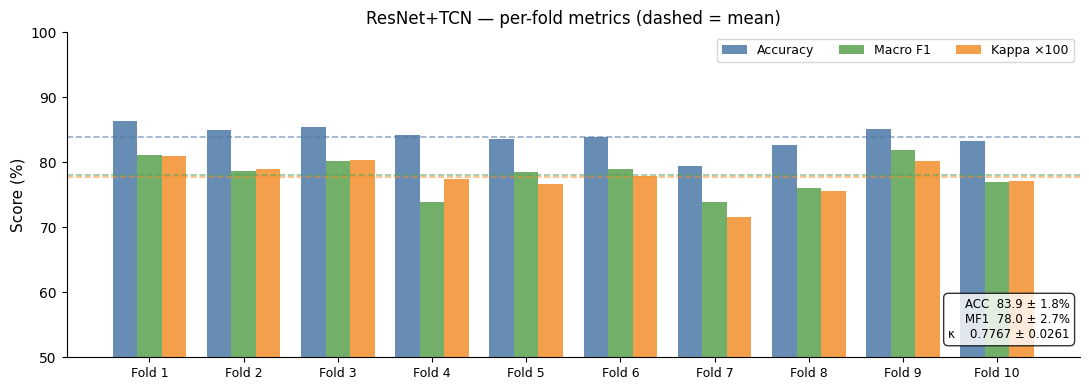

✓ Per-fold chart saved

Hypnogram: fold 1 (ACC=86.43%)


RuntimeError: Error(s) in loading state_dict for SleepTCN:
	Unexpected key(s) in state_dict: "scl_proj.0.weight", "scl_proj.0.bias", "scl_proj.2.weight", "scl_proj.2.bias". 

In [15]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — Visualization (Confusion Matrix, Per-fold, Hypnogram)
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix

STAGE_COLORS = {'W':'#4e79a7','N1':'#f28e2b','N2':'#59a14f','N3':'#e15759','REM':'#b07aa1'}
STAGE_LIST   = ['W', 'N1', 'N2', 'N3', 'REM']

def _despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 1. Confusion Matrix ───────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(6, 5))
cm       = confusion_matrix(all_trues, all_preds, labels=list(range(N_CLASSES)))
cm_pct   = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=STAGE_LIST, yticklabels=STAGE_LIST,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Recall (%)'},
            ax=ax, vmin=0, vmax=100)
ax.set_xlabel('Predicted stage', fontsize=11)
ax.set_ylabel('True stage', fontsize=11)
ax.set_title('Confusion matrix — ResNet+TCN (row-normalised, %)', fontsize=12, pad=10)
for i in range(N_CLASSES):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='#333', lw=2, clip_on=False))
fig1.tight_layout()
fig1.savefig(OUT_DIR / 'cm_tcn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Confusion matrix saved')

# ── 2. Per-fold metrics ────────────────────────────────────────────
folds  = [m['fold']       for m in fold_metrics]
accs   = [m['acc'] * 100  for m in fold_metrics]
mf1s   = [m['mf1'] * 100  for m in fold_metrics]
kappas = [m['kappa'] * 100 for m in fold_metrics]
x, width = np.arange(len(folds)), 0.26
fig2, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width, accs,   width, label='Accuracy',   color='#4e79a7', alpha=0.85)
ax.bar(x,          mf1s,  width, label='Macro F1',   color='#59a14f', alpha=0.85)
ax.bar(x + width, kappas, width, label='Kappa ×100', color='#f28e2b', alpha=0.85)
for vals, color in [(accs,'#4e79a7'),(mf1s,'#59a14f'),(kappas,'#f28e2b')]:
    ax.axhline(np.mean(vals), color=color, lw=1.2, ls='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f}' for f in folds], fontsize=9)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('ResNet+TCN — per-fold metrics (dashed = mean)', fontsize=12)
ax.set_ylim(50, 100)
ax.legend(fontsize=9, ncol=3)
_despine(ax)
stats_txt = (f"ACC  {np.mean(accs):.1f} ± {np.std(accs):.1f}%\n"
             f"MF1  {np.mean(mf1s):.1f} ± {np.std(mf1s):.1f}%\n"
             f"κ    {np.mean(kappas)/100:.4f} ± {np.std(kappas)/100:.4f}")
ax.text(0.99, 0.05, stats_txt, transform=ax.transAxes, fontsize=8.5,
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8))
fig2.tight_layout()
fig2.savefig(OUT_DIR / 'per_fold_tcn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Per-fold chart saved')

# ── 3. Hypnogram ──────────────────────────────────────────────────
best_fold_idx = int(np.argmax([m['acc'] for m in fold_metrics]))
best_fold     = fold_metrics[best_fold_idx]
print(f'\nHypnogram: fold {best_fold["fold"]} (ACC={best_fold["acc"]*100:.2f}%)')

best_resnet = EEG_ResNet1D(feature_dim=N_FEAT, num_classes=N_CLASSES).to(DEVICE)
best_resnet.load_state_dict(
    torch.load(CKPT_DIR / f'resnet_fold{best_fold["fold"]}.pth',
               map_location=DEVICE, weights_only=True))
best_resnet.eval()

best_tcn = SleepTCN(input_size=N_FEAT).to(DEVICE)
best_tcn.load_state_dict(
    torch.load(TCN_CKPT_DIR / f'tcn_scl_seqaug_fold{best_fold["fold"]}.pth',
               map_location=DEVICE, weights_only=True))
best_tcn.eval()

test_sids_best = list(fold_groups[best_fold_idx])
test_recs_best = [r for s in test_sids_best for r in subject_records[s]]
rec = max(test_recs_best, key=lambda r: (r['lbls'] >= 0).sum())

feat_rec = extract_features_resnet([rec], best_resnet)
feats, lbls = feat_rec[0]

with torch.no_grad():
    xb   = torch.from_numpy(feats.astype(np.float32)).unsqueeze(0).to(DEVICE)
    prob = best_tcn(xb).squeeze(0).cpu().numpy()
pred_all = prob.argmax(axis=1)

valid_mask = (lbls >= 0) & (lbls < N_CLASSES)
true_seq, pred_seq = lbls[valid_mask], pred_all[valid_mask]
T, time_hrs = len(true_seq), np.arange(len(true_seq)) * 30 / 3600
STAGE_Y = {'W': 4, 'N1': 3, 'N2': 2, 'N3': 1, 'REM': 0}

fig3, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True,
                           gridspec_kw={'hspace': 0.08})
for ax_idx, (seq, title) in enumerate(
        [(true_seq, 'True labels'), (pred_seq, 'SleepTCN predictions')]):
    ax = axes[ax_idx]
    for t in range(T):
        stage = STAGE_LIST[seq[t]]
        ax.fill_between(
            [time_hrs[t], time_hrs[t] + 30/3600],
            [STAGE_Y[stage] - 0.45]*2, [STAGE_Y[stage] + 0.45]*2,
            color=STAGE_COLORS[stage], alpha=0.85, linewidth=0)
    step_y = [STAGE_Y[STAGE_LIST[s]] for s in seq]
    ax.step(time_hrs, step_y, where='post', color='#222', lw=0.8, alpha=0.5)
    ax.set_yticks(list(STAGE_Y.values()))
    ax.set_yticklabels(list(STAGE_Y.keys()), fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(-0.6, 4.6)
    ax.grid(axis='x', ls=':', lw=0.5, alpha=0.5)
    _despine(ax)

axes[1].set_xlabel('Time (hours from recording start)', fontsize=11)
patches = [mpatches.Patch(color=STAGE_COLORS[s], label=s) for s in STAGE_LIST]
axes[0].legend(handles=patches, ncol=5, fontsize=9, loc='upper right', framealpha=0.85)
rec_acc = (true_seq == pred_seq).mean() * 100
fig3.suptitle(f'Sleep hypnogram — {rec["fname"]} (epoch ACC = {rec_acc:.1f}%)',
              fontsize=12, y=1.01)
fig3.tight_layout()
fig3.savefig(OUT_DIR / 'hypnogram_tcn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Hypnogram saved  (record ACC={rec_acc:.1f}%)')